In [11]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\y.com\OneDrive\Documents\Projects\House price prediction\notebooks
['House_price_prediction.ipynb']


In [4]:
import pandas as pd

df = pd.read_csv("../data/AmesHousing.csv")

print(df.head())
print(df.shape)


   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [5]:
df.isnull().sum().sort_values(ascending=False)


Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64

In [6]:
df = df.drop(columns=["Order", "PID"])

#### Let's separate features and target

In [7]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

identify data types

In [8]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

C:\Users\y.com\AppData\Local\Temp\ipykernel_32728\1085263280.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Numerical → numbers

Categorical → text/categories

train/test_split

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y_log,
    test_size = 0.2,
    random_state = 42
)
# 80% of trainig
# 20% of testing

preprocessing

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

Numerical
missing → median

Categorical
missing → most frequent
       → one-hot encoding

In [23]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MS SubClass','MS Zoning','Lot Frontage',...,'Yr Sold','Sale Type', 'Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This su

In [24]:
y_pred = model.predict(x_test)

y_test → actual prices

y_pred → predicted prices

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2= r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $0.08
MSE:  0.01
RMSE: $0.12
R²:   0.9199


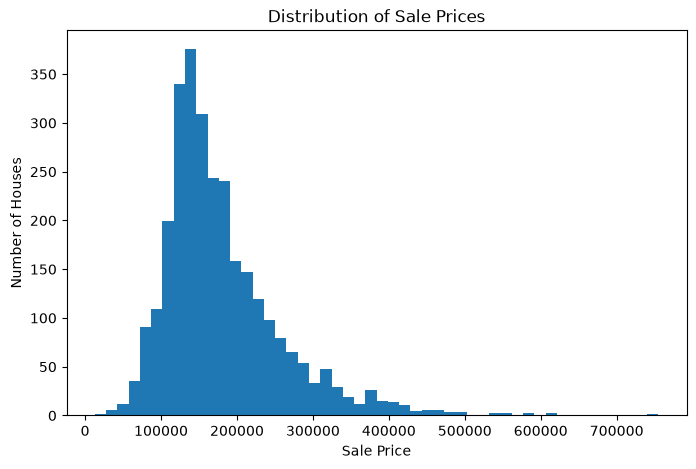

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=50)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of Sale Prices")
plt.show()

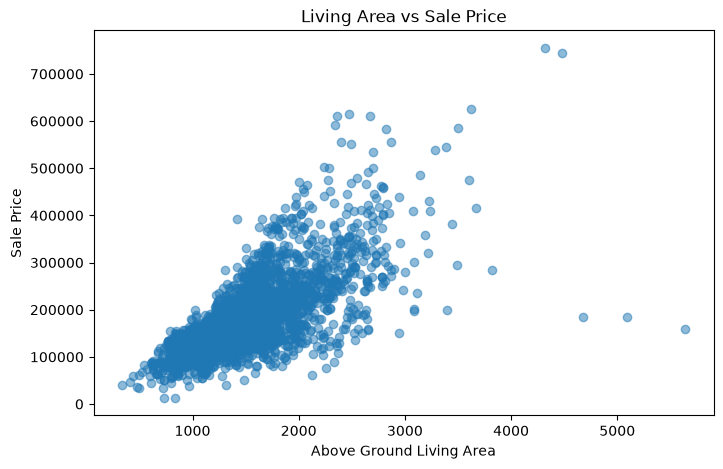

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.5)
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")
plt.show()

In [28]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

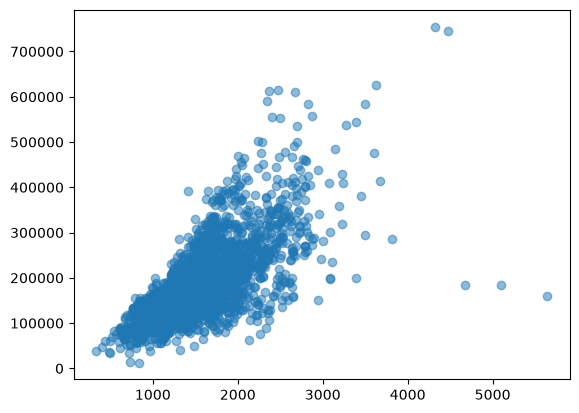

In [29]:
plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.5)

In [30]:
print(X.shape)
print(y.shape)

(2930, 79)
(2930,)


82 original columns
- 1 target (SalePrice)
- 2 identifiers (Order, PID)
= 79 features

In [31]:
import numpy as np
y_log = np.log1p(y)

Why log1p()?

Instead of learning:

100,000 → 200,000 → 300,000 → 500,000 → 750,000

the model learns on a compressed scale.

Very large prices don't dominate as strongly.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

In [34]:
model_log = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

model_log.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MS SubClass','MS Zoning','Lot Frontage',...,'Yr Sold','Sale Type', 'Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This su

In [35]:
y_pred_log = model_log.predict(x_test)

In [40]:
y_pred_price = np.expm1(y_pred_log)
y_test_price = np.expm1(y_test)

In [41]:
mae_log = mean_absolute_error(y_test_price, y_pred_price)
mse_log = mean_squared_error(y_test_price, y_pred_price)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_test_price, y_pred_price)

print(f"MAE:  ${mae_log:,.2f}")
print(f"MSE:  {mse_log:,.2f}")
print(f"RMSE: ${rmse_log:,.2f}")
print(f"R²:   {r2_log:.4f}")

MAE:  $16,448.84
MSE:  988,552,402.12
RMSE: $31,441.25
R²:   0.8767


In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

Train

Important: use the original y, not y_log.

rf_model.fit(X_train, y_train)

But there's a catch.

Your current y_train was created using y_log in the previous experiment.

So let's reset the split properly:

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MS SubClass','MS Zoning','Lot Frontage',...,'Yr Sold','Sale Type', 'Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This su

In [51]:
y_pred_rf = rf_model.predict(X_test)

In [54]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE:  ${mae_rf:,.2f}")
print(f"MSE:  {mse_rf:,.2f}")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

MAE:  $15,661.56
MSE:  706,351,350.62
RMSE: $26,577.27
R²:   0.9119


### experiment 4 — Gradient Boosting

Random Forest builds many trees independently and averages them.

Gradient Boosting works differently:

In [55]:
dense_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

dense_preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", dense_categorical_pipeline, categorical_cols)
])

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocessor", dense_preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

train and preidct

In [58]:
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)


### Evaluate

In [60]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MAE:  ${mae_gb:,.2f}")
print(f"MSE:  {mse_gb:,.2f}")
print(f"RMSE: ${rmse_gb:,.2f}")
print(f"R²:   {r2_gb:.4f}")

MAE:  $14,640.05
MSE:  630,550,114.58
RMSE: $25,110.76
R²:   0.9214


## Cross Validation
The problem with one train/test split is that our result depends partly on which houses happened to land in the test set.

In [61]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Log Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        17553,
        16448.84,
        15661.56,
        14640.05
    ],
    "RMSE": [
        30216.15,
        31441.25,
        26577.27,
        25110.76
    ],
    "R2": [
        0.8861,
        0.8767,
        0.9119,
        0.9214
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,17553.00,30216.15,0.8861
1,Log Linear Regression,16448.84,31441.25,0.8767
2,Random Forest,15661.56,26577.27,0.9119
3,Gradient Boosting,14640.05,25110.76,0.9214


In [62]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -cv_scores

print("Fold RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

Fold RMSE: [25134.17957176 21429.85469287 21408.90042713 22364.45444407
 20001.62487231]
Mean RMSE: 22067.80280162853
Std RMSE: 1708.852834947069


Here, cv=kf tells cross_val_score:
“Use the splitting strategy defined in kf (5 folds, shuffled, reproducible) when doing cross‑validation."

### Hyperparameter Tuning

The model doesn't learn them automatically from the training data—we choose them.

We're going to test different combinations.

In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}


In [83]:
grid_search = GridSearchCV(
    gb_model,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1 
)

In [84]:
grid_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 

In [85]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

Best CV RMSE:
21407.82963836668


Final Test Evaluation

In [86]:
best_model = grid_search.best_estimator_

In [87]:
y_pred_best = best_model.predict(X_test)

In [ ]:
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"MAE: ${mae_best:,.2f}")
print(f"MSE: ${mse_best:,.2f}")
print(f"RMSE: ${rmse_best:,.2f}")
print(f"R²: ${r2_best:,.6f}")

MAE: $7,201.50
MSE: $90,863,144.73
RMSE: $9,532.22
R^2: $0.988667


## Error Analysis

In [96]:
errors = y_test - y_pred_best
absolute_errors = np.abs(errors)

error_analysis = pd.DataFrame({
    "Actual": y_test,
    "predicted": y_pred_best,
    "Error": errors,
    "Absolute_error": absolute_errors
})

error_analysis = error_analysis.sort_values(
    "Absolute_error",
    ascending=False
)

error_analysis.head(10)

,Actual,predicted,Error,Absolute_error
2620,135000,89790.632664,45209.367336,45209.367336
2103,276000,316518.752874,-40518.752874,40518.752874
944,230000,269170.798005,-39170.798005,39170.798005
2392,344133,306264.105438,37868.894562,37868.894562
2422,246990,214518.259277,32471.740723,32471.740723
1538,311500,283130.798346,28369.201654,28369.201654
108,130500,158539.427725,-28039.427725,28039.427725
1569,228500,200499.751198,28000.248802,28000.248802
2246,235000,261621.608054,-26621.608054,26621.608054
2250,215000,188457.934573,26542.065427,26542.065427


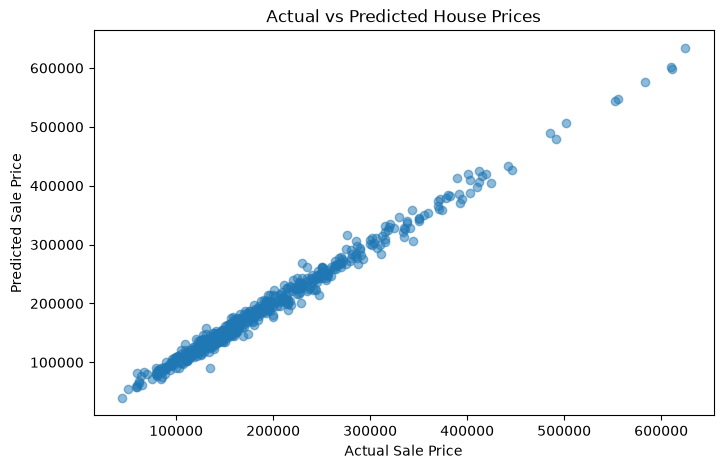

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_best, alpha=0.5)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [98]:
print("Training houses:", len(X_train))
print("Testing houses:", len(X_test))

Training houses: 2344
Testing houses: 586


In [99]:
print("Best CV RMSE:", -grid_search.best_score_)
print("Final Test RMSE:", rmse_best)

Best CV RMSE: 21407.82963836668
Final Test RMSE: 9532.216149785907


## Save model

In [104]:
import joblib

joblib.dump(
    best_model,
    "house_price_model.joblib"
)

['house_price_model.joblib']

In [105]:
import joblib

joblib.dump(
    best_model,
    "../models/house_price_model.joblib"
)

['../models/house_price_model.joblib']